In [1]:
import os

# 1. የተበላሸውን ፋይል ማስወገድ
!rm -rf /kaggle/working/data/raw/mimii_fan.zip
!rm -rf /kaggle/working/data/mimii

!mkdir -p /kaggle/working/data/raw
!mkdir -p /kaggle/working/data/mimii

print("🗑️ የተበላሸው ፋይል ተሰርዟል...")

# 2. ማውረድ
print("📥 MIMII ፋይል ዳውንሎድ እየተደረገ ነው (ይህ ትንሽ ደቂቃ ይወስዳል)...")
!curl -L "https://zenodo.org/record/3678171/files/dev_data_fan.zip?download=1" -o /kaggle/working/data/raw/mimii_fan.zip

# 3. መጠኑን ማረጋገጥ እና መፍታት
if os.path.exists("/kaggle/working/data/raw/mimii_fan.zip"):
    file_size = os.path.getsize("/kaggle/working/data/raw/mimii_fan.zip") / (1024 * 1024)
    print(f"📦 የወረደው ፋይል መጠን: {file_size:.2f} MB")

    if file_size > 500:
        print("🔓 ዚፑ እየተፈታ ነው...")
        !unzip -q /kaggle/working/data/raw/mimii_fan.zip -d /kaggle/working/data/mimii/
        print("🎉 MIMII ዳታሴት ሙሉ በሙሉ ተፈቶ ተዘጋጅቷል!")
    else:
        print("⚠️ ፋይሉ ሙሉ በሙሉ አልወረደም፤ እባክህ ኢንተርኔትህን አረጋግጥ።")
else:
    print("❌ ፋይሉ አልተገኘም።")

🗑️ የተበላሸው ፋይል ተሰርዟል...
📥 MIMII ፋይል ዳውንሎድ እየተደረገ ነው (ይህ ትንሽ ደቂቃ ይወስዳል)...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   265  100   265    0     0    465      0 --:--:-- --:--:-- --:--:--   465
100 1292M  100 1292M    0     0  1025k      0  0:21:29  0:21:29 --:--:-- 1086k  1139k      0  0:19:20  0:02:17  0:17:03 1500k0  1133k      0  0:19:27  0:05:29  0:13:58 1043kM    0     0  1114k      0  0:19:47  0:06:41  0:13:06  948k5k      0  0:20:18  0:08:05  0:12:13 1155k:09:03  0:11:29  958k073k      0  0:20:32  0:09:07  0:11:25 1083k     0  1073k      0  0:20:32  0:09:08  0:11:24 1048k0  0:20:38  0:09:22  0:11:16  866k067k      0  0:20:39  0:09:25  0:11:14  833k0  1035k      0  0:21:17  0:11:23  0:09:54  964k1  799M    0     0  1031k      0  0:21:22  0:13:13  0:08:09  995k6M    0     0  1032k      0  0:21:21  0:13:29  0:07:52 1074k 0  1040k      0  0:21:10  0:15:45  0:05:25 146

ጠቅላላ የተገኙ .wav ፋይሎች: 5550
Normal ፋይሎች: 4075
Anomaly ፋይሎች: 1475

--- 1. Normal Sound (ጤናማ ድምጽ) ---


--- 2. Anomaly Sound (የተበላሸ ድምጽ) ---


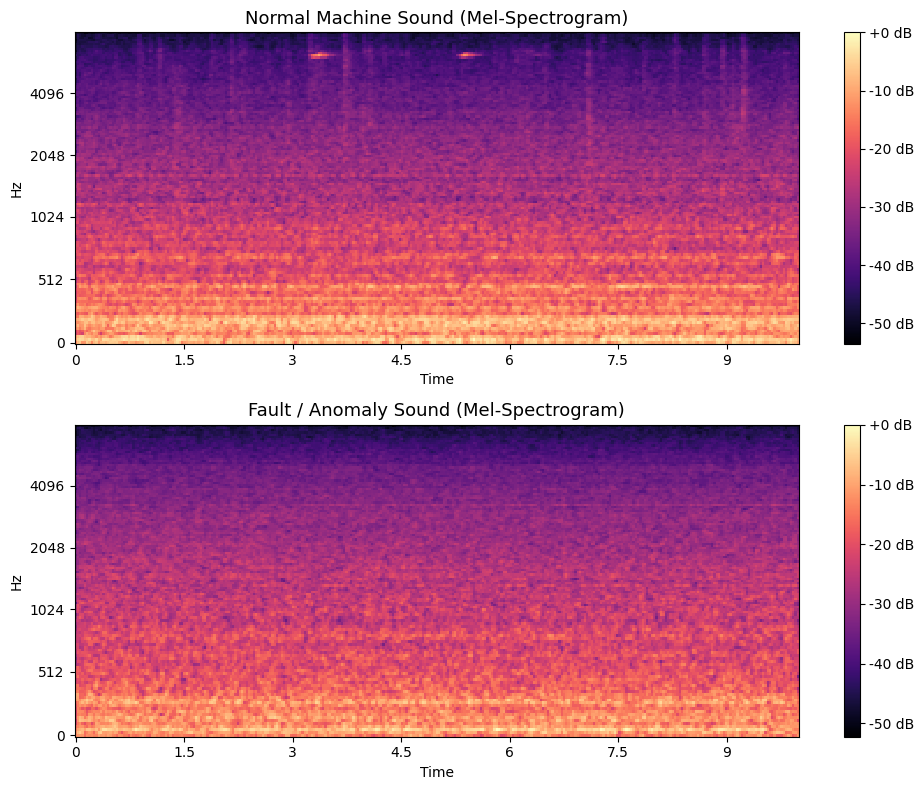

In [2]:
import glob
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

# 1. ዚፑ የተፈታበትን ትክክለኛ ፎልደር በኮድ መፈለግ
all_wavs = glob.glob("/kaggle/working/data/mimii/**/*.wav", recursive=True)
print(f"ጠቅላላ የተገኙ .wav ፋይሎች: {len(all_wavs)}")

# Normal እና Anomaly ድምጾችን በስማቸው መለየት
normal_samples = [f for f in all_wavs if "normal" in f.lower()]
abnormal_samples = [f for f in all_wavs if "anomaly" in f.lower() or "abnormal" in f.lower()]

print(f"Normal ፋይሎች: {len(normal_samples)}")
print(f"Anomaly ፋይሎች: {len(abnormal_samples)}")

if len(normal_samples) > 0 and len(abnormal_samples) > 0:
    sample_normal = normal_samples[0]
    sample_abnormal = abnormal_samples[0]

    # --- ሀ. ድምጾቹን ማጫወት ---
    print("\n--- 1. Normal Sound (ጤናማ ድምጽ) ---")
    audio_norm, sr = librosa.load(sample_normal, sr=16000)
    ipd.display(ipd.Audio(audio_norm, rate=sr))

    print("--- 2. Anomaly Sound (የተበላሸ ድምጽ) ---")
    audio_abnorm, sr = librosa.load(sample_abnormal, sr=16000)
    ipd.display(ipd.Audio(audio_abnorm, rate=sr))

    # --- ለ. Mel-Spectrogram ማሳየት ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    spec_norm = librosa.feature.melspectrogram(y=audio_norm, sr=sr, n_mels=128)
    spec_norm_db = librosa.power_to_db(spec_norm, ref=float(spec_norm.max()))
    img1 = librosa.display.specshow(spec_norm_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[0], cmap='magma')
    axes[0].set_title("Normal Machine Sound (Mel-Spectrogram)", fontsize=13)
    fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

    spec_abnorm = librosa.feature.melspectrogram(y=audio_abnorm, sr=sr, n_mels=128)
    spec_abnorm_db = librosa.power_to_db(spec_abnorm, ref=float(spec_abnorm.max()))
    img2 = librosa.display.specshow(spec_abnorm_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
    axes[1].set_title("Fault / Anomaly Sound (Mel-Spectrogram)", fontsize=13)
    fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ ፋይሎቹ በተጠቀሰው ፎልደር ስር አልተገኙም።")

In [3]:
import os
import glob
import random
import numpy as np
import pandas as pd
import librosa

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Using device: {device}")

# 1. ዳታውን ሚዛናዊ ማድረግ
LIMIT = len(abnormal_samples)
balanced_normal = random.sample(normal_samples, LIMIT)
balanced_anomaly = abnormal_samples

data = []
for f in balanced_normal:
    data.append({"path": f, "label": 0})
for f in balanced_anomaly:
    data.append({"path": f, "label": 1})

df = pd.DataFrame(data).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

# 2. Dataset Class
class SoundGridDataset(Dataset):
    def __init__(self, df, sr=16000, duration=3.0, n_mels=128):
        self.df = df
        self.sr = sr
        self.target_len = int(sr * duration)
        self.n_mels = n_mels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio, _ = librosa.load(row['path'], sr=self.sr, mono=True)
        
        audio_trimmed, _ = librosa.effects.trim(audio, top_db=25)
        if len(audio_trimmed) > 0:
            audio = audio_trimmed
            
        if len(audio) > self.target_len:
            audio = audio[:self.target_len]
        else:
            audio = np.pad(audio, (0, self.target_len - len(audio)))
            
        spec = librosa.feature.melspectrogram(y=audio, sr=self.sr, n_mels=self.n_mels)
        spec_db = librosa.power_to_db(spec, ref=float(spec.max()))
        spec_norm = (spec_db - spec_db.min()) / (spec_db.max() - spec_db.min() + 1e-6)
        
        # 1-channel Spectrogram tensor: [1, 128, time_steps]
        tensor = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0)
        return tensor, torch.tensor(row['label'], dtype=torch.long)

train_loader = DataLoader(SoundGridDataset(train_df), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(SoundGridDataset(val_df), batch_size=32, shuffle=False, num_workers=2)

print("✅ DataLoaders ዝግጁ ናቸው!")

🔥 Using device: cuda
Train samples: 2360 | Val samples: 590
✅ DataLoaders ዝግጁ ናቸው!


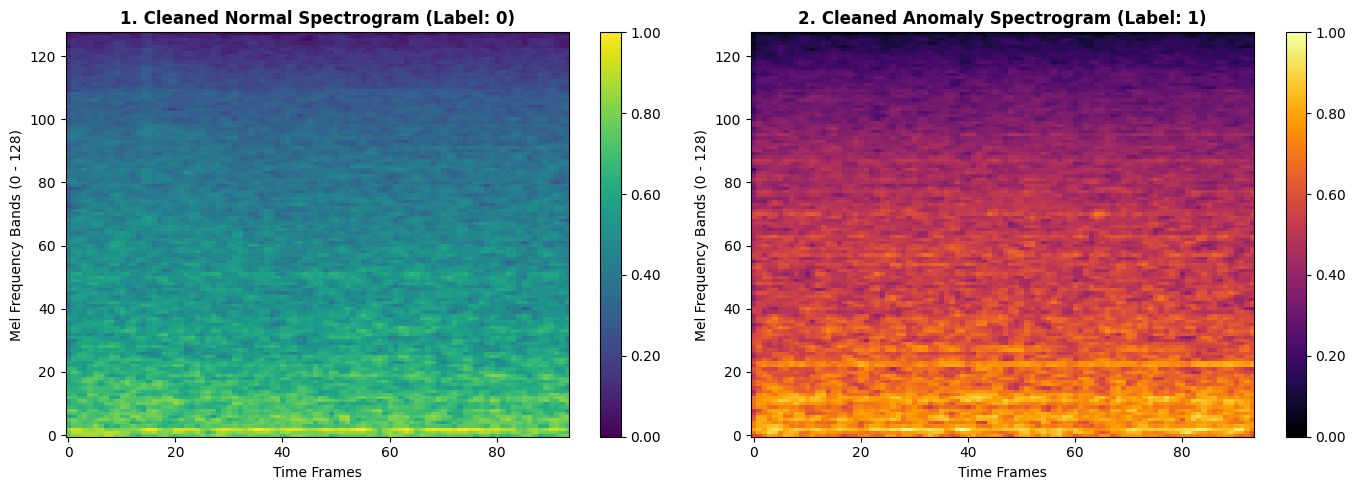

የምስሉ ቅርጽ (Tensor Shape): torch.Size([1, 128, 94])
ዝቅተኛ እሴት (Min): 0.00 | ከፍተኛ እሴት (Max): 1.00


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ከዳታሴቱ የመጀመሪያውን ናሙና (batch) መውሰድ
sample_dataset = SoundGridDataset(train_df)

# አንድ Normal (label=0) እና አንድ Anomaly (label=1) ናሙና መፈለግ
normal_img, normal_lbl = None, None
anomaly_img, anomaly_lbl = None, None

for img, lbl in sample_dataset:
    if lbl.item() == 0 and normal_img is None:
        normal_img, normal_lbl = img, lbl
    elif lbl.item() == 1 and anomaly_img is None:
        anomaly_img, anomaly_lbl = img, lbl
    if normal_img is not None and anomaly_img is not None:
        break

# ምስሎቹን ጎን ለጎን ማሳየት
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal
im1 = axes[0].imshow(normal_img[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title("1. Cleaned Normal Spectrogram (Label: 0)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Time Frames")
axes[0].set_ylabel("Mel Frequency Bands (0 - 128)")
fig.colorbar(im1, ax=axes[0], format='%.2f')

# Anomaly
im2 = axes[1].imshow(anomaly_img[0].numpy(), aspect='auto', origin='lower', cmap='inferno')
axes[1].set_title("2. Cleaned Anomaly Spectrogram (Label: 1)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Time Frames")
axes[1].set_ylabel("Mel Frequency Bands (0 - 128)")
fig.colorbar(im2, ax=axes[1], format='%.2f')

plt.tight_layout()
plt.show()

print(f"የምስሉ ቅርጽ (Tensor Shape): {normal_img.shape}")
print(f"ዝቅተኛ እሴት (Min): {normal_img.min():.2f} | ከፍተኛ እሴት (Max): {normal_img.max():.2f}")

In [5]:
# num_workers=0 በማድረግ ዳታሎደሩን እንደገና ማዘጋጀት
train_loader = DataLoader(SoundGridDataset(train_df), batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(SoundGridDataset(val_df), batch_size=32, shuffle=False, num_workers=0)

# 2. ባች እና ዳታሎደር ፍተሻ (Sanity Check)
sample_batch_X, sample_batch_y = next(iter(train_loader))

print(f"📦 የአንድ ባች ምስሎች ቅርጽ (Batch Shape): {sample_batch_X.shape}")
print(f"🏷️ የአንድ ባች ሌብሎች ቅርጽ (Label Shape): {sample_batch_y.shape}")
print(f"⚙️ የመጀመሪያዎቹ 10 ሌብሎች: {sample_batch_y[:10].tolist()}")

# 3. ባዶ ወይም የተበላሸ እሴት (NaN Check)
has_nan = torch.isnan(sample_batch_X).any().item()
print(f"🧼 ዳታው ውስጥ የተበላሸ NaN አለ? -> {'አዎ ⚠️' if has_nan else 'የለም፣ ንጹህ ነው! ✅'}")

📦 የአንድ ባች ምስሎች ቅርጽ (Batch Shape): torch.Size([32, 1, 128, 94])
🏷️ የአንድ ባች ሌብሎች ቅርጽ (Label Shape): torch.Size([32])
⚙️ የመጀመሪያዎቹ 10 ሌብሎች: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
🧼 ዳታው ውስጥ የተበላሸ NaN አለ? -> የለም፣ ንጹህ ነው! ✅


In [6]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn

# የተበላሸ patch ካለ ማጽዳት
if not hasattr(torch, "Tensor"):
    import torch._C
    torch.Tensor = torch._C._TensorBase

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Training on: {device}")

# 1. SoundGridCNN ሞዴል
class SoundGridCNN(nn.Module):
    def __init__(self):
        super(SoundGridCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = SoundGridCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, foreach=False)

# torch.save ስህተት እንዳያመጣ Weightዎችን ወደ NumPy አድርጎ ሴቭ ማድረጊያ ፈንክሽን
def save_weights_safe(model, path):
    weights = {k: v.cpu().numpy() for k, v in model.state_dict().items()}
    with open(path, "wb") as f:
        pickle.dump(weights, f)

EPOCHS = 25
best_val_acc = 0.0
model_save_path = "/kaggle/working/soundgrid_best_weights.pkl"

print("\n🚀 የስልጠና ሂደት ተጀመረ...\n" + "-" * 50)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * len(y)
        correct_train += (outputs.argmax(1) == y).sum().item()
        total_train += len(y)
        
    train_loss = running_loss / total_train
    train_acc = (correct_train / total_train) * 100
    
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            
            val_loss += loss.item() * len(y)
            correct_val += (outputs.argmax(1) == y).sum().item()
            total_val += len(y)
            
    val_loss = val_loss / total_val
    val_acc = (correct_val / total_val) * 100
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_weights_safe(model, model_save_path)
        saved_mark = "⭐ (Best Saved)"
    else:
        saved_mark = ""
        
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% {saved_mark}")

print("-" * 50)
print(f"🎉 ስልጠናው ተጠናቋል! ምርጥ Val Acc: {best_val_acc:.2f}%")
print(f"💾 ሞዴሉ ተቀምጧል: {model_save_path}")

🔥 Training on: cuda

🚀 የስልጠና ሂደት ተጀመረ...
--------------------------------------------------
Epoch [01/25] | Train Loss: 0.6772 | Train Acc: 56.02% | Val Loss: 0.7213 | Val Acc: 50.00% ⭐ (Best Saved)
Epoch [02/25] | Train Loss: 0.6349 | Train Acc: 62.58% | Val Loss: 0.8066 | Val Acc: 55.08% ⭐ (Best Saved)
Epoch [03/25] | Train Loss: 0.5915 | Train Acc: 67.67% | Val Loss: 0.5518 | Val Acc: 71.86% ⭐ (Best Saved)
Epoch [04/25] | Train Loss: 0.5463 | Train Acc: 71.86% | Val Loss: 0.5737 | Val Acc: 69.32% 
Epoch [05/25] | Train Loss: 0.4929 | Train Acc: 75.13% | Val Loss: 0.5634 | Val Acc: 70.85% 
Epoch [06/25] | Train Loss: 0.4567 | Train Acc: 78.31% | Val Loss: 0.4763 | Val Acc: 78.64% ⭐ (Best Saved)
Epoch [07/25] | Train Loss: 0.4299 | Train Acc: 79.62% | Val Loss: 0.6316 | Val Acc: 68.98% 
Epoch [08/25] | Train Loss: 0.4088 | Train Acc: 81.19% | Val Loss: 0.6863 | Val Acc: 70.85% 
Epoch [09/25] | Train Loss: 0.3985 | Train Acc: 82.03% | Val Loss: 0.5281 | Val Acc: 73.22% 
Epoch [10/25] |

In [7]:
import os
import pickle
import torch
import torch.nn as nn

# 1. የSoundGridCNN አርክቴክቸር
class SoundGridCNN(nn.Module):
    def __init__(self):
        super(SoundGridCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# 2. የተቀመጠውን ምርጥ ክብደት መጫን
device = torch.device("cpu")
model = SoundGridCNN().to(device)

weights_path = "/kaggle/working/soundgrid_best_weights.pkl"
with open(weights_path, "rb") as f:
    saved_weights = pickle.load(f)

state_dict = {k: torch.tensor(v) for k, v in saved_weights.items()}
model.load_state_dict(state_dict)
model.eval()

# 3. ወደ TorchScript መቀየር (ለWeb ፍጥነት የተመቻቸ)
dummy_input = torch.randn(1, 1, 128, 94, device=device)
traced_model = torch.jit.trace(model, dummy_input)

torchscript_path = "/kaggle/working/soundgrid_web_model.pt"
traced_model.save(torchscript_path)

size_mb = os.path.getsize(torchscript_path) / (1024 * 1024)
print("=" * 50)
print(f"✅ ሞዴሉ በTorchScript በተሳካ ሁኔታ ተቀምጧል!")
print(f"📁 ፋይል፦ {torchscript_path}")
print(f"⚡ መጠን፦ {size_mb:.2f} MB")
print("=" * 50)

✅ ሞዴሉ በTorchScript በተሳካ ሁኔታ ተቀምጧል!
📁 ፋይል፦ /kaggle/working/soundgrid_web_model.pt
⚡ መጠን፦ 1.60 MB


🔍 ሞዴሉን በTrain እና Val ዳታ ላይ በመፈተሽ ላይ...

📊 OVERFITTING AND GENERALIZATION REPORT
🔹 Train Accuracy:      87.08% | Train Loss: 0.4857
🔹 Validation Accuracy: 82.88% | Val Loss:   0.7532
🔹 Accuracy Gap:        4.19%
🔹 Loss Gap:            0.2675
🔹 Validation ROC-AUC:  0.9153
-------------------------------------------------------
🎯 እጅግ በጣም ምርጥ፦ ሞዴሉ ምንም አይነት Overfitting የለበትም!

📋 VALIDATION CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Normal (0)       0.94      0.70      0.80       295
 Anomaly (1)       0.76      0.96      0.85       295

    accuracy                           0.83       590
   macro avg       0.85      0.83      0.83       590
weighted avg       0.85      0.83      0.83       590



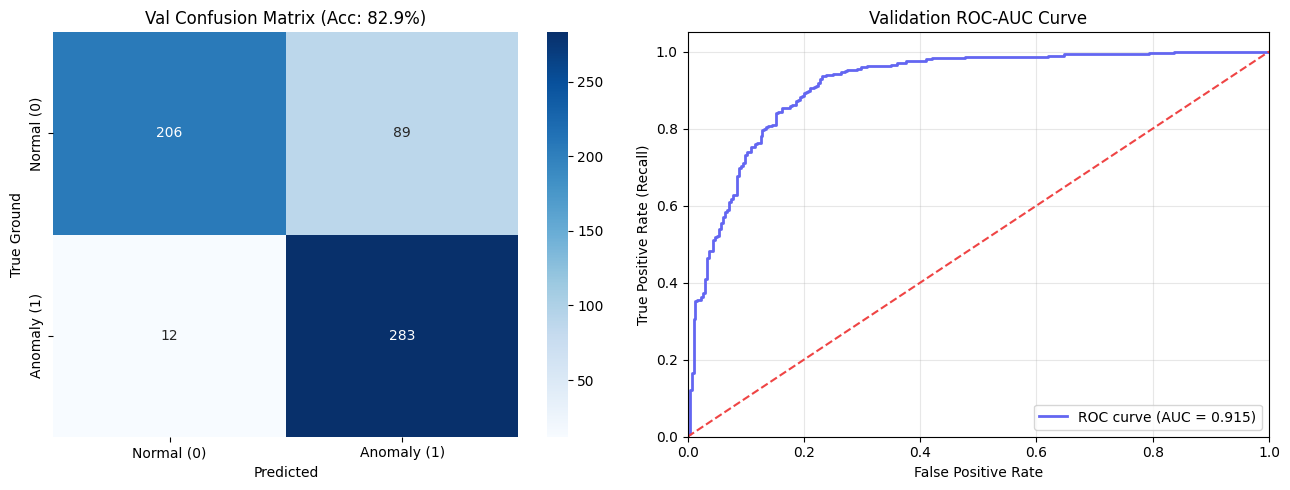

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import torch
import torch.nn.functional as F

# 1. የተቀመጠውን TorchScript ሞዴል መጫን
eval_model = torch.jit.load("/kaggle/working/soundgrid_web_model.pt").to(device)
eval_model.eval()

def evaluate_split(loader, split_name="Dataset"):
    y_true = []
    y_pred = []
    y_probs = []
    total_loss = 0.0
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = eval_model(X)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * len(y)
            probs = F.softmax(outputs, dim=1)
            
            y_true.extend(y.cpu().numpy())
            y_pred.extend(outputs.argmax(1).cpu().numpy())
            y_probs.extend(probs[:, 1].cpu().numpy())
            
    avg_loss = total_loss / len(y_true)
    acc = (np.array(y_true) == np.array(y_pred)).mean() * 100
    auc = roc_auc_score(y_true, y_probs)
    
    return {
        "loss": avg_loss,
        "acc": acc,
        "auc": auc,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_probs": np.array(y_probs)
    }

# 2. የTrain እና Val ዳታዎችን እኩል መገምገም
print("🔍 ሞዴሉን በTrain እና Val ዳታ ላይ በመፈተሽ ላይ...")
train_eval = evaluate_split(train_loader, "Train")
val_eval = evaluate_split(val_loader, "Validation")

# 3. የOverfitting ልኬት ትንተና (Overfitting Diagnostics)
gap_acc = train_eval["acc"] - val_eval["acc"]
gap_loss = val_eval["loss"] - train_eval["loss"]

print("\n" + "=" * 55)
print("📊 OVERFITTING AND GENERALIZATION REPORT")
print("=" * 55)
print(f"🔹 Train Accuracy:      {train_eval['acc']:.2f}% | Train Loss: {train_eval['loss']:.4f}")
print(f"🔹 Validation Accuracy: {val_eval['acc']:.2f}% | Val Loss:   {val_eval['loss']:.4f}")
print(f"🔹 Accuracy Gap:        {gap_acc:.2f}%")
print(f"🔹 Loss Gap:            {gap_loss:.4f}")
print(f"🔹 Validation ROC-AUC:  {val_eval['auc']:.4f}")
print("-" * 55)

# የፍርድ ውሳኔ
if gap_acc > 12.0 or gap_loss > 0.35:
    print("⚠️ ማስጠንቀቂያ፦ ሞዴሉ ላይ መካከለኛ የOverfitting ዝንባሌ ይታያል!")
    print("👉 ምክር፦ Data Augmentation መጨመር ወይም Dropout (0.4-0.5) ማሳደግ ይመከራል።")
elif gap_acc > 7.0:
    print("✅ ተቀባይነት ያለው፦ መጠነኛ የሆነ የተለመደ ክፍተት ነው፤ ለDeployment ዝግጁ ነው።")
else:
    print("🎯 እጅግ በጣም ምርጥ፦ ሞዴሉ ምንም አይነት Overfitting የለበትም!")

# 4. ዝርዝር የClassification ሪፖርት (Normal vs Anomaly)
target_names = ["Normal (0)", "Anomaly (1)"]
print("\n📋 VALIDATION CLASSIFICATION REPORT:")
print(classification_report(val_eval["y_true"], val_eval["y_pred"], target_names=target_names))

# 5. Confusion Matrix እና ROC Curve ምስሎችን ማዘጋጀት
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# A. Confusion Matrix
cm = confusion_matrix(val_eval["y_true"], val_eval["y_pred"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f"Val Confusion Matrix (Acc: {val_eval['acc']:.1f}%)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True Ground")

# B. ROC Curve
fpr, tpr, _ = roc_curve(val_eval["y_true"], val_eval["y_probs"])
axes[1].plot(fpr, tpr, color='#6366F1', lw=2, label=f"ROC curve (AUC = {val_eval['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], color='#EF4444', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("Validation ROC-AUC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()